## 2. Exploratory Analysis and Visualization

### 2.0 Setup -> To be deleted once merged

In [82]:
!java -version
!pip install pyspark
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless;

openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-124.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-124.04, mixed mode, sharing)
Hit:1 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease
Hit:2 https://download.docker.com/linux/ubuntu noble InRelease                 
Hit:3 https://cli.github.com/packages stable InRelease                         
Hit:4 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease  
Hit:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:6 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-security InRelease 
Hit:7 https://packages.cloud.google.com/apt cloud-sdk InRelease                
Hit:8 https://security.ubuntu.com/ubuntu noble-security InRelease              
Hit:9 http://deb.wakemeops.com/wakemeops stable InRelease           
Hit:10 https://archive.ubuntu.com/ubuntu noble InRelease
Hit:11 https://archive.ubuntu.com/ubuntu noble-updates InRelease
Hi

In [83]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("EDAFlightData") \
    .config("spark.sql.debug.maxToStringFields", 1000) \
    .getOrCreate()

In [84]:
df = spark.read.parquet("/teamspace/studios/this_studio/BigDataProject/data/parquet_flights")

### 2.1 Basic Profiling

The US Domestic Flights Delay Dataset from 2013-2018 was collected as part of the AWS Academy's Machine Learning Foundations course. This dataset contains schedualed and actual departure and arrival times reported by certified US air carriers that account for at least 1 percent of domestic scheduled passenger reveneues. The data was collected by the U.S. Office of Airline Information, Bureau of Transportation Statistics (BTS). The dataset contains date, time, origin, destination, airline, distance, and delay status of flights for flights between 2013 and 2018.


In this project, we will just consider the last two years, 2017 and 2018, since the dataset is huge and with these period we can fully meet the required criteria and start working with PySpark. 


In this section, 

#### 2.1.1 Count, schema, paritions

In [85]:
df.printSchema()

root
 |-- FL_DATE: date (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- OP_CARRIER_FL_NUM: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- CRS_DEP_TIME: integer (nullable = true)
 |-- DEP_TIME: float (nullable = true)
 |-- DEP_DELAY: float (nullable = true)
 |-- TAXI_OUT: float (nullable = true)
 |-- WHEELS_OFF: float (nullable = true)
 |-- WHEELS_ON: float (nullable = true)
 |-- TAXI_IN: float (nullable = true)
 |-- CRS_ARR_TIME: integer (nullable = true)
 |-- ARR_TIME: float (nullable = true)
 |-- ARR_DELAY: float (nullable = true)
 |-- CANCELLED: float (nullable = true)
 |-- DIVERTED: float (nullable = true)
 |-- CRS_ELAPSED_TIME: float (nullable = true)
 |-- ACTUAL_ELAPSED_TIME: float (nullable = true)
 |-- AIR_TIME: float (nullable = true)
 |-- DISTANCE: float (nullable = true)
 |-- CARRIER_DELAY: float (nullable = true)
 |-- WEATHER_DELAY: float (nullable = true)
 |-- NAS_DELAY: float (nullable = true)
 |--

The original dataset contains 109 variables, however, we dropped many of them since the majority of them consisted of missing values. Here are the columns that we are going to take a deeper look at with an explanation of them: 

- `FL_DATE`: Calendar date of the flight.  
- `OP_CARRIER`: Airline operating the flight.  
- `OP_CARRIER_FL_NUM`: Flight number used by the reporting airline.  
- `ORIGIN`: Origin airport code.  
- `DEST`: Destination airport code.  
- `CRS_DEP_TIME`: Scheduled departure time (hhmm).  
- `DEP_TIME`: Actual departure time (hhmm).  
- `DEP_DELAY`: Minutes difference between scheduled and actual departure.  
- `TAXI_OUT`: Minutes spent taxiing out before takeoff.  
- `WHEELS_OFF`: Time the aircraft lifted off (hhmm).  
- `WHEELS_ON`: Time the aircraft landed (hhmm).  
- `TAXI_IN`: Minutes spent taxiing after landing.  
- `CRS_ARR_TIME`: Scheduled arrival time (hhmm).  
- `ARR_TIME`: Actual arrival time (hhmm).  
- `ARR_DELAY`: Minutes difference between scheduled and actual arrival.  
- `CANCELLED`: Indicates if the flight was cancelled (1=yes).  
- `DIVERTED`: Indicates if the flight was diverted (1=yes).  
- `CRS_ELAPSED_TIME`: Scheduled total flight duration.  
- `ACTUAL_ELAPSED_TIME`: Actual total flight duration.  
- `AIR_TIME`: Time spent airborne.  
- `DISTANCE`: Distance between origin and destination in miles.  
- `CARRIER_DELAY`: Delay attributed to the airline.  
- `WEATHER_DELAY`: Delay caused by weather conditions.  
- `NAS_DELAY`: Delay caused by the National Airspace System.  
- `SECURITY_DELAY`: Delay caused by security issues.  
- `LATE_AIRCRAFT_DELAY`: Delay caused by the late arrival of the aircraft.  
- `IsDelayed`: Flag indicating if arrival delay exceeded your defined threshold.  
- `Year`: Year of the flight date.  
- `Month`: Month of the flight date.


Let's take a look at the first five rows of our dataset:

In [86]:
df.show(5, truncate=False)

+----------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+---------+----+-----+
|FL_DATE   |OP_CARRIER|OP_CARRIER_FL_NUM|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|DIVERTED|CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|AIR_TIME|DISTANCE|CARRIER_DELAY|WEATHER_DELAY|NAS_DELAY|SECURITY_DELAY|LATE_AIRCRAFT_DELAY|IsDelayed|Year|Month|
+----------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+---------+----+-----+
|2017-06-01|VX        |108  

There are **12,688,790** flight delay records in the dataset.  
This count **excludes cancelled flights**, which were removed for simplicity.  
All analyses therefore focus only on flights that actually operated.


In [87]:
df.count()

12688790

As previously written, we will just explore the years 2017 and 2018 which are divided into 12 months. 

In [88]:
df.select("Year", "Month").distinct().orderBy("Year", "Month").show(30)

+----+-----+
|Year|Month|
+----+-----+
|2017|    1|
|2017|    2|
|2017|    3|
|2017|    4|
|2017|    5|
|2017|    6|
|2017|    7|
|2017|    8|
|2017|    9|
|2017|   10|
|2017|   11|
|2017|   12|
|2018|    1|
|2018|    2|
|2018|    3|
|2018|    4|
|2018|    5|
|2018|    6|
|2018|    7|
|2018|    8|
|2018|    9|
|2018|   10|
|2018|   11|
|2018|   12|
+----+-----+



The following code shows how many pieces (partitions) our DataFrame is split into for parallel processing in Spark, which is 4 partitions.

In [89]:
df.rdd.getNumPartitions()

4

#### 2.1.2 Missing values per columns

We have already dropped the columns were the majority of the records were null, however, you can see that still some the variables like `WHEELS_ON`, `ARR_TIME`, `ACTUAL_ELAPSED_TIME` and many more have still some missing values. Since the number of the missing values are negligible in comparison to the total number of records, we will just drop the NA ones if we want to perform some operation on them.

In [90]:
missing_df = (
    df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])
)
missing_df.show()


+-------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+---------+----+-----+
|FL_DATE|OP_CARRIER|OP_CARRIER_FL_NUM|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|DIVERTED|CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|AIR_TIME|DISTANCE|CARRIER_DELAY|WEATHER_DELAY|NAS_DELAY|SECURITY_DELAY|LATE_AIRCRAFT_DELAY|IsDelayed|Year|Month|
+-------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+---------+----+-----+
|      0|         0|                0

#### 2.1.3 Duplicate Rows

The dataframe contains **no duplicated rows**, meaning each record represents a unique flight observation.


In [91]:
dups = df.count() - df.dropDuplicates().count()
print("Duplicate rows:", dups)

25/12/11 19:13:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/11 19:13:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/11 19:13:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/11 19:13:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/11 19:13:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/11 19:13:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/11 19:13:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/11 19:13:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/11 19:13:20 WARN RowBasedKeyValueBatch: Calling spill() on

Duplicate rows: 0


### 2.2 Summary Statistics

Summary statistics reduce a large dataset into key values—such as mean, median, and standard deviation—that quickly show its central tendency, variability, and overall distribution.

To do this we use the `describe()` function. However, its output is stored as **strings**, so we cannot directly apply rounding.  
To control the number of decimals, we must first cast the string values to numeric types, then round them.

Read more about this here: https://stackoverflow.com/questions/72862898/round-df-describe-results/79833269#79833269

#### 2.2.1 Descriptive stats for all numeric columns

In [92]:
numeric_cols = [f.name for f in df.schema.fields if f.dataType.simpleString() in ["double", "float", "int", "bigint"]]

# Compute description only for numeric columns
describe = df.select(numeric_cols).describe()

# Format each numeric column to 2 decimals
for column in numeric_cols:
    describe = describe.withColumn(column, format_number(col(column).cast('double'), 2))

describe.show()

+-------+-----------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+----------------+-------------------+-------------+-------------+-------------+-------------+-------------+--------------+-------------------+-------------+-------------+-------------+
|summary|OP_CARRIER_FL_NUM| CRS_DEP_TIME|     DEP_TIME|    DEP_DELAY|     TAXI_OUT|   WHEELS_OFF|    WHEELS_ON|      TAXI_IN| CRS_ARR_TIME|     ARR_TIME|    ARR_DELAY|    CANCELLED|     DIVERTED|CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|     AIR_TIME|     DISTANCE|CARRIER_DELAY|WEATHER_DELAY|    NAS_DELAY|SECURITY_DELAY|LATE_AIRCRAFT_DELAY|    IsDelayed|         Year|        Month|
+-------+-----------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+----------------+-------------------+--------

#### 2.2.2 Additioanl stasts (min/ max/ stddev)

In [93]:
min_stats = df.select(*[round(min(c), 0).alias(f"{c}_min") for c in numeric_cols])
max_stats = df.select(*[round(max(c), 0).alias(f"{c}_max") for c in numeric_cols])
stddev_stats = df.select(*[round(stddev(c), 0).alias(f"{c}_std") for c in numeric_cols])

print('Minimum values are: ')
min_stats.show()

print('Maximum values are: ')
max_stats.show()

print('The standard deviations are: ')
stddev_stats.show()

Minimum values are: 


+---------------------+----------------+------------+-------------+------------+--------------+-------------+-----------+----------------+------------+-------------+-------------+------------+--------------------+-----------------------+------------+------------+-----------------+-----------------+-------------+------------------+-----------------------+-------------+--------+---------+
|OP_CARRIER_FL_NUM_min|CRS_DEP_TIME_min|DEP_TIME_min|DEP_DELAY_min|TAXI_OUT_min|WHEELS_OFF_min|WHEELS_ON_min|TAXI_IN_min|CRS_ARR_TIME_min|ARR_TIME_min|ARR_DELAY_min|CANCELLED_min|DIVERTED_min|CRS_ELAPSED_TIME_min|ACTUAL_ELAPSED_TIME_min|AIR_TIME_min|DISTANCE_min|CARRIER_DELAY_min|WEATHER_DELAY_min|NAS_DELAY_min|SECURITY_DELAY_min|LATE_AIRCRAFT_DELAY_min|IsDelayed_min|Year_min|Month_min|
+---------------------+----------------+------------+-------------+------------+--------------+-------------+-----------+----------------+------------+-------------+-------------+------------+--------------------+-------

+---------------------+----------------+------------+-------------+------------+--------------+-------------+-----------+----------------+------------+-------------+-------------+------------+--------------------+-----------------------+------------+------------+-----------------+-----------------+-------------+------------------+-----------------------+-------------+--------+---------+
|OP_CARRIER_FL_NUM_max|CRS_DEP_TIME_max|DEP_TIME_max|DEP_DELAY_max|TAXI_OUT_max|WHEELS_OFF_max|WHEELS_ON_max|TAXI_IN_max|CRS_ARR_TIME_max|ARR_TIME_max|ARR_DELAY_max|CANCELLED_max|DIVERTED_max|CRS_ELAPSED_TIME_max|ACTUAL_ELAPSED_TIME_max|AIR_TIME_max|DISTANCE_max|CARRIER_DELAY_max|WEATHER_DELAY_max|NAS_DELAY_max|SECURITY_DELAY_max|LATE_AIRCRAFT_DELAY_max|IsDelayed_max|Year_max|Month_max|
+---------------------+----------------+------------+-------------+------------+--------------+-------------+-----------+----------------+------------+-------------+-------------+------------+--------------------+-------

+---------------------+----------------+------------+-------------+------------+--------------+-------------+-----------+----------------+------------+-------------+-------------+------------+--------------------+-----------------------+------------+------------+-----------------+-----------------+-------------+------------------+-----------------------+-------------+--------+---------+
|OP_CARRIER_FL_NUM_std|CRS_DEP_TIME_std|DEP_TIME_std|DEP_DELAY_std|TAXI_OUT_std|WHEELS_OFF_std|WHEELS_ON_std|TAXI_IN_std|CRS_ARR_TIME_std|ARR_TIME_std|ARR_DELAY_std|CANCELLED_std|DIVERTED_std|CRS_ELAPSED_TIME_std|ACTUAL_ELAPSED_TIME_std|AIR_TIME_std|DISTANCE_std|CARRIER_DELAY_std|WEATHER_DELAY_std|NAS_DELAY_std|SECURITY_DELAY_std|LATE_AIRCRAFT_DELAY_std|IsDelayed_std|Year_std|Month_std|
+---------------------+----------------+------------+-------------+------------+--------------+-------------+-----------+----------------+------------+-------------+-------------+------------+--------------------+-------

### 2.3 Flights EDA

#### 2.3.1 Distribution of delays

Seeing the distribution of delays helps us understand how delays are spread, identify common delay ranges, detect outliers, and spot patterns or anomalies.


In [94]:
summary = df.select("DEP_DELAY", "ARR_DELAY").summary()

for column in ["DEP_DELAY", "ARR_DELAY"]:
    summary = summary.withColumn(column, round(col(column), 2))

summary.show()

+-------+----------+----------+
|summary| DEP_DELAY| ARR_DELAY|
+-------+----------+----------+
|  count|1.268879E7|1.268879E7|
|   mean|      9.83|      4.72|
| stddev|     44.32|      46.4|
|    min|    -234.0|    -238.0|
|    25%|      -5.0|     -14.0|
|    50%|      -2.0|      -6.0|
|    75%|       7.0|       7.0|
|    max|    2755.0|    2692.0|
+-------+----------+----------+



#### 2.3.2 Diversions

A flight is marked as diverted when it does not land at its scheduled destination and instead lands at a different airport. This can happen due to weather, technical issues, or air traffic problems.

Looking at diversions helps to see which flights or routes are most affected and why. It also gives an idea of how reliable the flights are and can help with planning and improving operations.


In [95]:
df.groupBy("DIVERTED").count().show()

+--------+--------+
|DIVERTED|   count|
+--------+--------+
|     1.0|   30374|
|     0.0|12658416|
+--------+--------+



#### 2.3.3 Delays by carriers

We can see that the following carriers have the most average amount of delay for both arrival and departures. 

- `B6`: JetBlue Airways  
- `F9`: Frontier Airlines  
- `G4`: Allegiant Air  

In [96]:
df.groupBy("OP_CARRIER").agg(
    avg("DEP_DELAY").alias("avg_dep_delay"),
    avg("ARR_DELAY").alias("avg_arr_delay"),
    count("*").alias("flights")
).orderBy("avg_dep_delay", ascending=False).show(15, truncate=False)

+----------+------------------+--------------------+-------+
|OP_CARRIER|avg_dep_delay     |avg_arr_delay       |flights|
+----------+------------------+--------------------+-------+
|B6        |16.181761996206856|11.178086006278896  |588957 |
|F9        |16.156314841105164|10.233355174547706  |219768 |
|G4        |12.923752252441018|9.956323597200686   |95452  |
|EV        |12.520876242181494|8.290978464108429   |526795 |
|OH        |11.9720729067809  |8.212538495875643   |266587 |
|VX        |11.832161495670126|9.251155588690715   |87185  |
|YV        |11.19325121178581 |8.831356627609633   |209608 |
|WN        |10.691681328961419|4.771667721847922   |2645675|
|9E        |10.45941760379359 |4.394060827677177   |239562 |
|OO        |10.178872098854752|7.039274566386863   |1459596|
|NK        |9.978004893934097 |5.354123354123354   |326118 |
|UA        |9.760287118970803 |3.804954718269321   |1195184|
|AA        |9.098591162896685 |4.637805745869593   |1786083|
|DL        |7.9489710297

#### 2.3.4 Delays by airport (origin & destination)

The most average amount of departure delays belongs to the following airports:

- `YNG`: Youngstown–Warren Regional Airport, serving Youngstown and Warren in Ohio, USA
- `UST`: Northeast Florida Regional Airport, near St. Augustine, Florida, USA
- `TKI`: McKinney National Airport, serving McKinney near Dallas–Fort Worth, Texas, USA


In [97]:
df.groupBy("ORIGIN").agg(avg("DEP_DELAY")).orderBy("avg(DEP_DELAY)", ascending=False).show(20)

+------+------------------+
|ORIGIN|    avg(DEP_DELAY)|
+------+------------------+
|   YNG|              63.0|
|   UST| 59.36923076923077|
|   TKI|              45.0|
|   ART|36.333333333333336|
|   OTH| 31.85202492211838|
|   OWB|27.635514018691588|
|   PPG|27.616666666666667|
|   MMH|26.976190476190474|
|   HGR| 26.76086956521739|
|   ACK| 26.09873417721519|
|   LWB| 25.70921985815603|
|   HYA|25.552486187845304|
|   MVY|24.507670850767084|
|   SCK|24.265856950067477|
|   PSM|24.225589225589225|
|   SLN|22.279411764705884|
|   BLV|21.368941641938676|
|   MEI|21.098859315589355|
|   EGE| 20.85078079814922|
|   PGV|20.678355501813783|
+------+------------------+
only showing top 20 rows



The most average amount of arrival delays belongs to the following airports:

- `YNG`: Youngstown–Warren Regional Airport, serving Youngstown and Warren in Ohio, USA
- `UST`: Northeast Florida Regional Airport, near St. Augustine, Florida, USA
- `OTH`: Southwest Oregon Regional Airport, the public airport in North Bend, Oregon, USA


In [98]:
df.groupBy("DEST").agg(avg("ARR_DELAY")).orderBy("avg(ARR_DELAY)", ascending=False).show(20)

+----+------------------+
|DEST|    avg(ARR_DELAY)|
+----+------------------+
| YNG|              59.5|
| UST|37.833333333333336|
| OTH|22.725731895223422|
| PPG|20.763485477178424|
| BKG|19.246376811594203|
| PGV|18.854567307692307|
| SFB| 18.44706746406463|
| PIB|17.729768786127167|
| MEI| 16.78411792677128|
| MMH| 16.35377358490566|
| EWR|16.092426941064932|
| SHD|15.874613003095975|
| BQN|15.632070135746606|
| CKB|15.589345172031077|
| PSE|15.555023923444976|
| LWB| 14.25925925925926|
| TTN|14.147882736156351|
| UIN|13.509394572025052|
| LYH|      13.376953125|
| SCK|13.201079622132253|
+----+------------------+
only showing top 20 rows



#### 2.3.5 Delays over time (month, year)

This table shows the average departure delay for different months and years.  

The numbers indicate that flights in summer months (June, July, August) tend to have higher delays, around **13–14 minutes on average**.  
This is likely because **summer is a busy travel season**, with more flights, higher passenger traffic, and occasional weather issues, all of which can increase delays.


In [99]:
df.groupBy("Year", "Month") \
  .agg(avg("DEP_DELAY").alias("avg_dep_delay")) \
  .orderBy("avg_dep_delay", ascending=False) \
  .show(30)


+----+-----+------------------+
|Year|Month|     avg_dep_delay|
+----+-----+------------------+
|2018|    8|13.684039726720648|
|2018|    7|13.575248811130592|
|2017|    6| 13.56975333768335|
|2017|    7|13.160045538263466|
|2018|    6|13.012679143264245|
|2017|    1|12.097084539513206|
|2017|    4|12.060918011589587|
|2017|    8|11.154239514339945|
|2017|    5|10.787788841813764|
|2018|    5|10.626355899660963|
|2017|   12| 9.905182389334055|
|2018|    1| 9.442760543919963|
|2018|   11| 9.434769038701623|
|2018|    2| 9.347730847768952|
|2017|    3| 9.270585539608808|
|2018|   12|   8.9806179631743|
|2018|    4| 8.419215151027052|
|2018|    3| 7.618164911460601|
|2018|    9| 7.353618401120466|
|2017|    2| 7.074222238715503|
|2018|   10| 6.972078886098467|
|2017|   10|  6.67582592855314|
|2017|    9| 5.287696443714704|
|2017|   11| 4.281501245737105|
+----+-----+------------------+



### 2.4. Sampling Strategy

Because our dataset is very large (over 12.7 million rows), we use a **small sample** of the data for visualization.  
This makes plots faster to create and easier to read while still showing the main patterns.

We use a **1% random sample** of the dataset for visualizations.  
This small subset is enough to show trends and patterns without slowing down Spark operations on the full dataset.


In [100]:
sample_pd = df.sample(False, 0.01, seed=42).toPandas()

### 2.5 Visualizations (Pandas/Matplotlib)

#### 2.5.1 Histogram of daprture delay

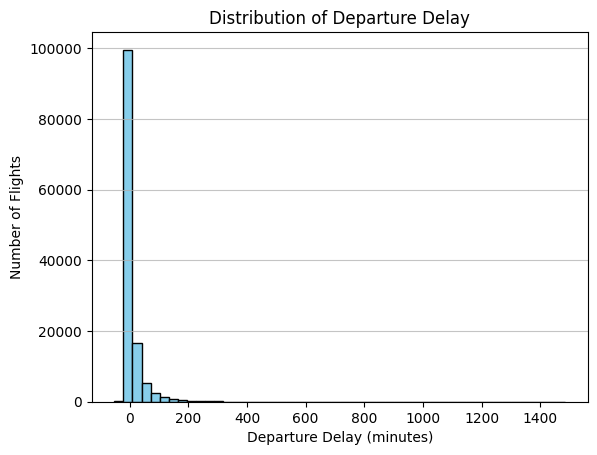

In [101]:
plt.hist(sample_pd["DEP_DELAY"].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Departure Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Number of Flights")
plt.grid(axis='y', alpha=0.75)
plt.show()

#### 2.5.2 Distribution of arrival delay

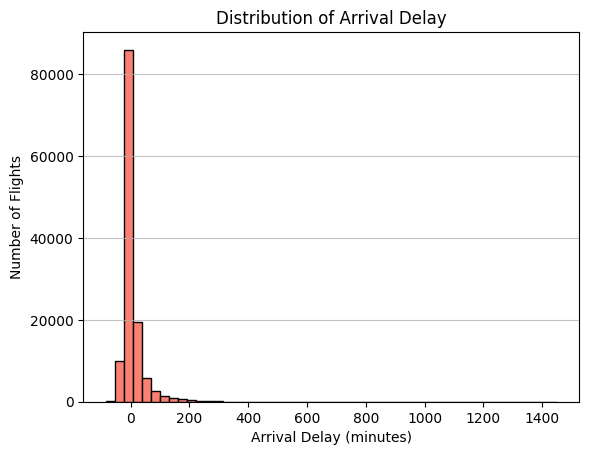

In [102]:
plt.hist(sample_pd["ARR_DELAY"].dropna(), bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of Arrival Delay")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.grid(axis='y', alpha=0.75)
plt.show()

#### 2.5.3 Delays by carrier

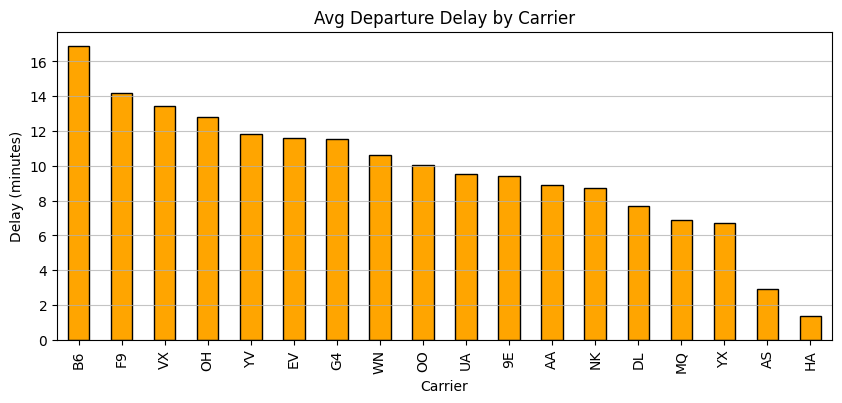

In [103]:
carrier_delay = (
    sample_pd.groupby("OP_CARRIER")["DEP_DELAY"]
             .mean()
             .sort_values(ascending=False)
)

carrier_delay.plot(kind="bar", figsize=(10,4), color='orange', edgecolor='black', title="Avg Departure Delay by Carrier")
plt.ylabel("Delay (minutes)")
plt.xlabel("Carrier")
plt.grid(axis='y', alpha=0.75)
plt.show()

#### 2.5.4 Delays by month

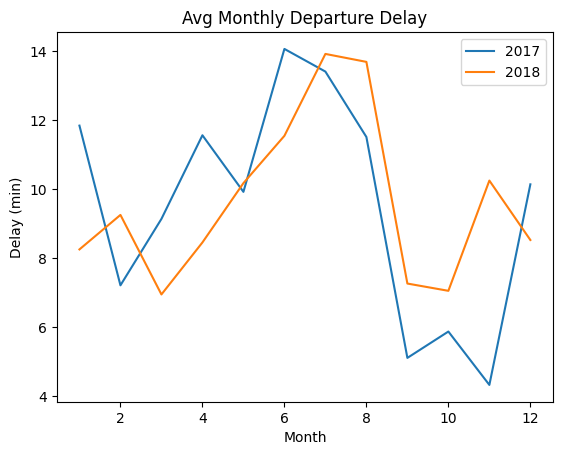

In [104]:
monthly_delay = (
    sample_pd.groupby(["Year", "Month"])["DEP_DELAY"]
             .mean()
             .reset_index()
)

for y in monthly_delay["Year"].unique():
    subset = monthly_delay[monthly_delay["Year"] == y]
    plt.plot(subset["Month"], subset["DEP_DELAY"], label=str(y))

plt.title("Avg Monthly Departure Delay")
plt.xlabel("Month")
plt.ylabel("Delay (min)")
plt.legend()
plt.show()


### 2.6 Correlation Analysis

In [105]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

corr_cols = [
    "DEP_DELAY",
    "ARR_DELAY",
    "DISTANCE",
    "CRS_ELAPSED_TIME",
    "ACTUAL_ELAPSED_TIME",
    "AIR_TIME",
]

# Since correlation requires non-null values, we drop rows wiht NA in these specific columns.
# we also cast the columns to Double type for the correlation calculation.
corr_df = df.select([col(c).cast("double").alias(c) for c in corr_cols]).na.drop()

# Assemble the columns into a single vector column
assembler = VectorAssembler(inputCols=corr_cols, outputCol="features")
vector_df = assembler.transform(corr_df).select("features")

# Calculate the Pearson Correlation Matrix
matrix = Correlation.corr(vector_df, "features", "pearson").collect()[0][0]

In [106]:
# Convert the PySpark DenseMatrix to a Pandas DataFrame
correlations = matrix.toArray().tolist()
corr_pd = pd.DataFrame(correlations, columns=corr_cols, index=corr_cols)

# Display the resulting correlation matrix
print("Correlation Matrix:")
print(corr_pd)

Correlation Matrix:
                     DEP_DELAY  ARR_DELAY  DISTANCE  CRS_ELAPSED_TIME  \
DEP_DELAY             1.000000   0.957149  0.011114          0.015438   
ARR_DELAY             0.957149   1.000000 -0.019345         -0.020701   
DISTANCE              0.011114  -0.019345  1.000000          0.983416   
CRS_ELAPSED_TIME      0.015438  -0.020701  0.983416          1.000000   
ACTUAL_ELAPSED_TIME   0.019185   0.034778  0.970635          0.983915   
AIR_TIME              0.010898  -0.001553  0.984737          0.989800   

                     ACTUAL_ELAPSED_TIME  AIR_TIME  
DEP_DELAY                       0.019185  0.010898  
ARR_DELAY                       0.034778 -0.001553  
DISTANCE                        0.970635  0.984737  
CRS_ELAPSED_TIME                0.983915  0.989800  
ACTUAL_ELAPSED_TIME             1.000000  0.988240  
AIR_TIME                        0.988240  1.000000  


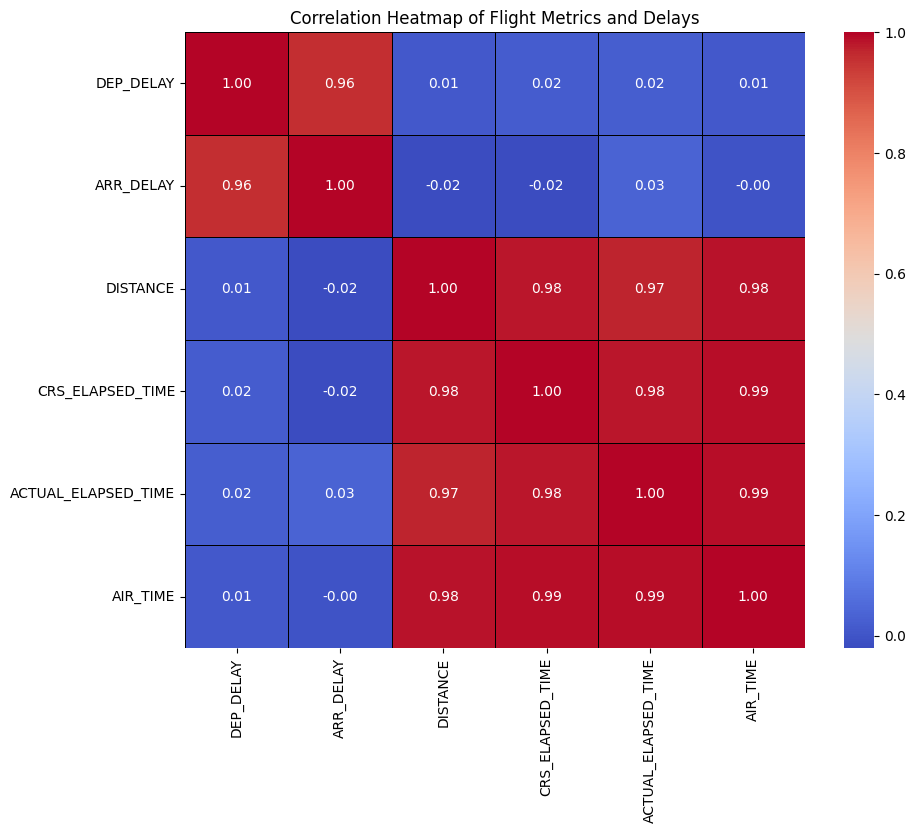

In [107]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_pd,
    annot=True,
    fmt=".2f",
    cmap="coolwarm", # 'coolwarm' is excellent for showing positive/negative
    cbar=True,
    linewidths=0.5,
    linecolor='black'
)
plt.title("Correlation Heatmap of Flight Metrics and Delays")
plt.show()

The correlation matrix shows that departure and arrival delays are highly correlated (0.96), meaning delays tend to propagate. Flight times (distance, scheduled, actual, and air time) are also strongly correlated (0.97–0.99), but delays have almost no relationship with flight distance or duration. Overall, delays are linked to each other, while flight times are interrelated independently of delays.


### 2.7 Delay Causes

In [108]:
delay_cause_cols = [
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

# 1. Fill NA values with 0 and cast to Integer for safe summation
delay_df = df.select([col(c).cast("int").alias(c) for c in delay_cause_cols]).fillna(0)

# 2. Calculate the total sum of delay minutes for each cause
total_delays = delay_df.agg(
    *[sum(col(c)).alias(f"Total_{c}") for c in delay_cause_cols]
).collect()[0]

# 3. Convert the Row object to a dictionary for easier processing
delay_dict = total_delays.asDict()

# Display the total minutes for each cause
print("Total Delay Minutes by Cause:")
for k, v in delay_dict.items():
    print(f"- {k}: {v:,} minutes")

Total Delay Minutes by Cause:
- Total_CARRIER_DELAY: 46,833,683 minutes
- Total_WEATHER_DELAY: 7,718,834 minutes
- Total_NAS_DELAY: 37,989,222 minutes
- Total_SECURITY_DELAY: 220,701 minutes
- Total_LATE_AIRCRAFT_DELAY: 60,594,128 minutes


In [109]:
# Prepare data for Pandas DataFrame
causes = [k.replace('Total_', '') for k in delay_dict.keys()]
minutes = list(delay_dict.values())

# Create a Pandas Series for the pie chart
delay_series = pd.Series(minutes, index=causes)

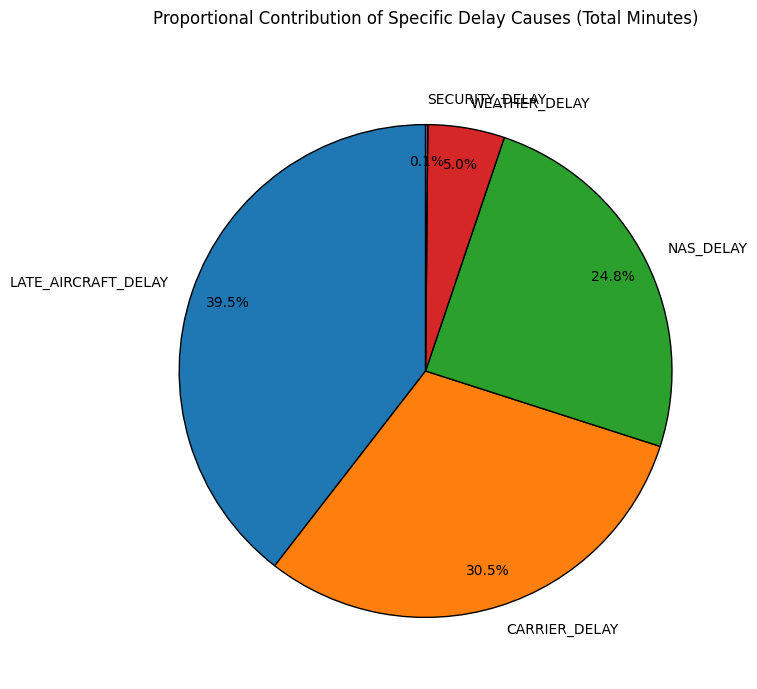

In [110]:
plt.figure(figsize=(10, 8))
delay_series.sort_values(ascending=False).plot(
    kind="pie",
    autopct="%1.1f%%", # Format to one decimal place
    startangle=90,
    pctdistance=0.85, # Position of the percentage text
    wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True}
)
plt.title("Proportional Contribution of Specific Delay Causes (Total Minutes)", y=1.05)
plt.ylabel("")
plt.show()

📉 Conclusion: Root Causes of Delay

Analysis of 153.3 million delay minutes (2017-2018) shows that operational issues, not weather, drive most delays. The "Ripple Effect" (39.5%) from late aircraft is the top cause, followed by airline-related factors like maintenance and crew (30.5%). Weather accounts for only 5%, while infrastructure and air traffic control contribute 24.8%.  

Bottom Line: Airlines control most delays, and addressing the ripple effect would yield the biggest improvement in on-time performance.


---